In [1]:
# Importing Required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing with NLTK & spaCy


## Task 1: Load and Explore the Dataset

**Objective:** Understand the data structure and perform basic Exploratory Data Analysis (EDA).

In this task, we will create a read a given dataset and explore it.

1. Check first 5 rows
2. Analyse Class distribution
3. Analyse Text Length


In [2]:
# 1.1 Read dataset
df = pd.read_csv('/content/emo_text.csv')
df.head()

,sentiment,content
0,negative,Layin n bed with a headache ughhhh...waitin o...
1,negative,Funeral ceremony...gloomy friday...
2,neutral,@dannycastillo We want to trade with someone w...
3,negative,"I should be sleep, but im not! thinking about ..."
4,negative,@charviray Charlene my love. I miss you


In [3]:
# 1.2 Basic Exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17289 entries, 0 to 17288
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  17289 non-null  object
 1   content    17289 non-null  object
dtypes: object(2)
memory usage: 270.3+ KB


In [4]:
df.isnull().sum()

,0
sentiment,0
content,0


In [5]:
df.columns


Index(['sentiment', 'content'], dtype='object')

In [6]:
# 1.3 Class Distribution Analysis
df['sentiment'].value_counts()

,count
sentiment,
neutral,8638
negative,7567
positive,1084


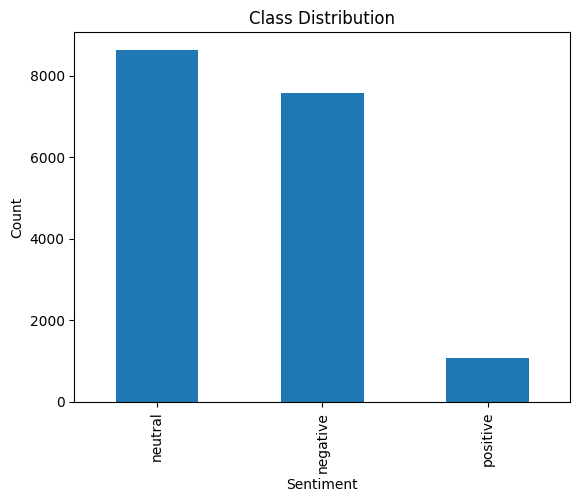

In [7]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [8]:
# 1.4 Text Length Analysis
df['content_length'] = df['content'].apply(len)
df[['content', 'content_length']].head()


,content,content_length
0,Layin n bed with a headache ughhhh...waitin o...,60
1,Funeral ceremony...gloomy friday...,35
2,@dannycastillo We want to trade with someone w...,86
3,"I should be sleep, but im not! thinking about ...",132
4,@charviray Charlene my love. I miss you,39


In [9]:
df['content_length'].describe()

,content_length
count,17289.000000
mean,73.347504
std,44.001671
min,1.000000
25%,40.000000
50%,65.000000
75%,103.000000
max,601.000000


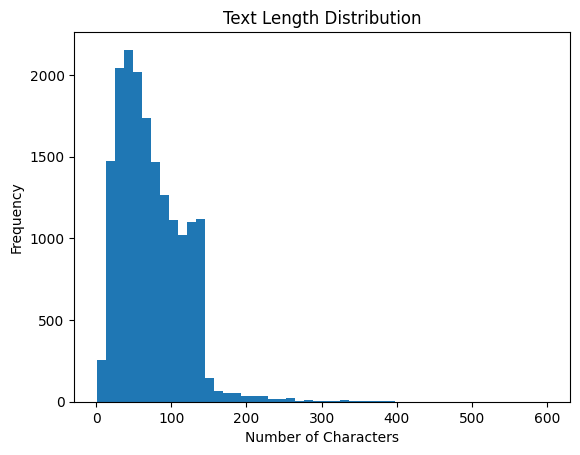

In [10]:
df['content_length'].plot(kind='hist', bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.show()


## Task 2: Text Pre-processing with NLTK

**Objective:** Learn the "classic" way of cleaning text using the Natural Language Toolkit (NLTK). We will cover Tokenization, Stopword Removal, and Stemming.

Write a python function `preprocess_nltk(text)` that does the following using `NLTK Library`:

1. Normalising the text (Lowercasing)
2. Tokenization (Splitting text into words)
3. Removing Punctuation and Stopwords
4. Stemming (Reducing words to their root form, e.g., "running" -> "run")

and return cleaned text

In [11]:
# NLTK Text Preprocessing

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string

# Download required NLTK data
nltk.download('punkt_tab')
nltk.download('stopwords')

# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Define preprocessing function
def nltk_preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing to dataset
df['NLTK_Cleaned'] = df['content'].apply(nltk_preprocess)

# Display result
print("Original vs NLTK Processed:")
display(df[['content', 'NLTK_Cleaned']].head())


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Original vs NLTK Processed:


,content,NLTK_Cleaned
0,Layin n bed with a headache ughhhh...waitin o...,layin n bed headach ughhhhwaitin call
1,Funeral ceremony...gloomy friday...,funer ceremonygloomi friday
2,@dannycastillo We want to trade with someone w...,dannycastillo want trade someon houston ticket...
3,"I should be sleep, but im not! thinking about ...",sleep im think old friend want he marri damn a...
4,@charviray Charlene my love. I miss you,charviray charlen love miss


## Task 3: Advanced Pre-processing with spaCy

**Objective:** Use spaCy's industrial-strength pipeline for efficient processing, focusing on Lemmatization.

wrtie a python function `preprocess_spacy(text` that does the follwoing thing using `spacy`:

1. Create a spaCy Doc object
2. Lemmatization and stopword removal

and return cleaned text

In [12]:
# Task 3: Text Preprocessing using spaCy

import spacy

# Load English language model
nlp = spacy.load("en_core_web_sm")

# Define spaCy preprocessing function
def spacy_preprocess(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    return " ".join(tokens)

# Apply preprocessing to dataset
df['spacy_cleaned'] = df['content'].apply(spacy_preprocess)

# Display original vs spaCy cleaned text
print("Original vs spaCy Processed:")
display(df[['content', 'spacy_cleaned']].head())


Original vs spaCy Processed:


,content,spacy_cleaned
0,Layin n bed with a headache ughhhh...waitin o...,layin n bed headache ughhhh waitin
1,Funeral ceremony...gloomy friday...,funeral ceremony gloomy friday
2,@dannycastillo We want to trade with someone w...,@dannycastillo want trade houston ticket
3,"I should be sleep, but im not! thinking about ...",sleep m think old friend want marry damn amp w...
4,@charviray Charlene my love. I miss you,@charviray charlene love miss


## Task 4: Feature Engineering (Bag of Words & TF-IDF)

**Objective:** Machines cannot understand text. We must convert text into numbers (vectors).

### 4.1 Count Vectorizer (Bag of Words)
This method counts how many times each word appears in a document.

In [13]:
# Task 4.1: Feature Extraction using Count Vectorizer

from sklearn.feature_extraction.text import CountVectorizer

# Initialize Count Vectorizer
count_vectorizer = CountVectorizer(max_features=5000)

# Fit and transform the spaCy cleaned text
X_count = count_vectorizer.fit_transform(df['spacy_cleaned'])

# Target labels
y = df['sentiment']

# Display shape of Count Vectorized matrix
print("Count Vectorizer Feature Matrix Shape:", X_count.shape)

# Display sample feature names
print("Sample Features:", count_vectorizer.get_feature_names_out()[:10])


Count Vectorizer Feature Matrix Shape: (17289, 5000)
Sample Features: ['00' '000' '02' '03' '05' '06' '07' '08' '09' '10']


### 4.2 TF-IDF (Term Frequency - Inverse Document Frequency)
This method highlights words that are important to a specific document but rare across the corpus (filtering out common words like "the", "is", etc., even if stopwords didn't catch them).

In [14]:
# Task 4.2: Feature Extraction using TF-IDF Vectorize

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the spaCy cleaned text
X_tfidf = tfidf_vectorizer.fit_transform(df['spacy_cleaned'])

# Target labels
y = df['sentiment']

# Display TF-IDF matrix shape
print("TF-IDF Feature Matrix Shape:", X_tfidf.shape)

# Display sample TF-IDF feature names
print("Sample TF-IDF Features:", tfidf_vectorizer.get_feature_names_out()[:10])



TF-IDF Feature Matrix Shape: (17289, 5000)
Sample TF-IDF Features: ['00' '000' '02' '03' '05' '06' '07' '08' '09' '10']


## Task 5: Sentiment Analysis Model

**Objective:** Build a Machine Learning classifier to predict sentiment based on our text features.

Write a python code that builds `MultinomiaNB` model that is trained on TF-IDF values and sentiment.

In [15]:
# Task 5: Train-Test Split and Model Training

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_count, y, test_size=0.2, random_state=42
)

# Initialize Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predict on test data
y_pred = nb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6902834008097166

Confusion Matrix:
 [[ 995  456   45]
 [ 491 1241   21]
 [  48   10  151]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.65      0.67      0.66      1496
     neutral       0.73      0.71      0.72      1753
    positive       0.70      0.72      0.71       209

    accuracy                           0.69      3458
   macro avg       0.69      0.70      0.69      3458
weighted avg       0.69      0.69      0.69      3458



## Task 6: Interactive Prediction

**Objective:** Test the model with new, unseen user input.


Write python function `predict_sentiment(text)` that predict the sentiment of the given text by performing the following:
1. Preprocess using our defined spaCy function
2. Vectorize using the fitted TF-IDF object
3. Prediction

and returns the predicted sentiment.

In [16]:
# Task 6: Sentiment Prediction for New Text

# Function to predict sentiment of new input text
def predict_sentiment(text):
    # Preprocess text using spaCy
    cleaned_text = spacy_preprocess(text)

    # Convert text to count vector
    vector = count_vectorizer.transform([cleaned_text])

    # Predict sentiment
    prediction = nb_model.predict(vector)

    return prediction[0]

# Test the function with sample inputs
print("Input: I really love this product")
print("Predicted Sentiment:", predict_sentiment("I really love this product"))

print("\nInput: This is the worst experience ever")
print("Predicted Sentiment:", predict_sentiment("This is the worst experience ever"))

print("\nInput: Good Product")
print("Predicted Sentiment:", predict_sentiment("Good Product"))

print("\nInput: Very Slow Delivery")
print("Predicted Sentiment:", predict_sentiment("Very Slow Delivery"))


Input: I really love this product
Predicted Sentiment: neutral

Input: This is the worst experience ever
Predicted Sentiment: negative

Input: Good Product
Predicted Sentiment: neutral

Input: Very Slow Delivery
Predicted Sentiment: negative


In [17]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,8638
negative,7567
positive,1084
